Best Parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l1'}
Best CV ROC AUC: 0.7320986879133249

Test Set Accuracy: 0.8466981132075472
Test Set ROC AUC: 0.7027525309700167

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.47      0.05      0.10       129

    accuracy                           0.85       848
   macro avg       0.66      0.52      0.51       848
weighted avg       0.79      0.85      0.79       848



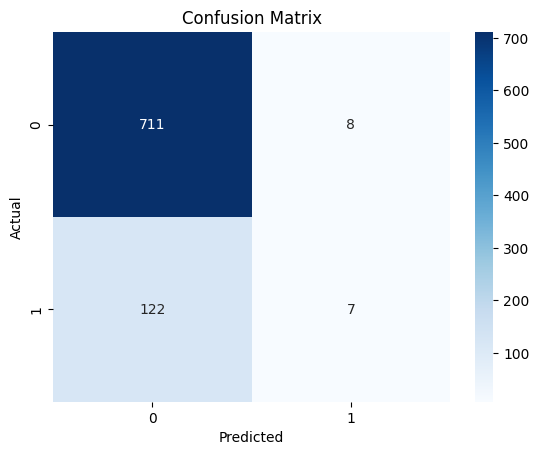

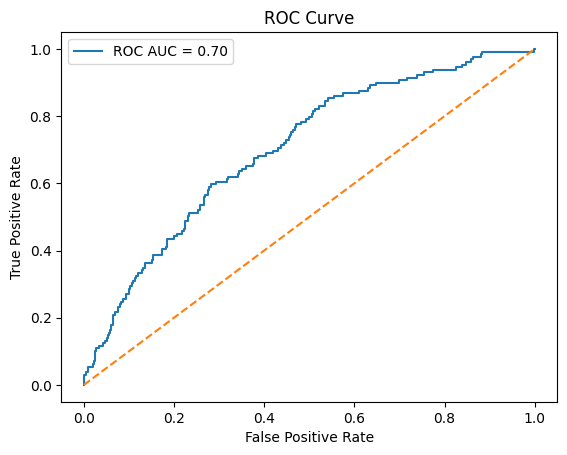


Model saved as 'logistic_model.pkl'.


In [2]:
# Heart Disease Risk Prediction using Logistic Regression
# Author: Krish
# Based on the Framingham Heart Study Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import joblib

# Load the cleaned dataset
df = pd.read_csv("framingham_cleaned.csv")

# Separate features and target
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Build the pipeline: scaler + logistic regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="liblinear", max_iter=1000))
])

# Define hyperparameters for grid search
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10],
    "logreg__penalty": ["l1", "l2"]
}

# Grid search with 5-fold cross-validation
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best CV ROC AUC:", grid.best_score_)

# Evaluate on the test set
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print("\nTest Set Accuracy:", accuracy_score(y_test, y_pred))
print("Test Set ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Save the model
joblib.dump(grid.best_estimator_, "logistic_model.pkl")
print("\nModel saved as 'logistic_model.pkl'.")
